## Empleo de Algoritmos Clásicos de Machine Learning en Imágenes

In [3]:
!pip install scikit-learn
!pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [26]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Las imagenes son de tamaño 28x28.
# Pero las imágenes ya vienen desdobladas en vectores (28x28=784)
# Son 70k imágenes

print(f"Forma de los datos: {X.shape}")
print(f"Estructura de las etiquetas: {y.shape}")

Forma de los datos: (70000, 784)
Estructura de las etiquetas: (70000,)


Etiqueta de la imagen: 6


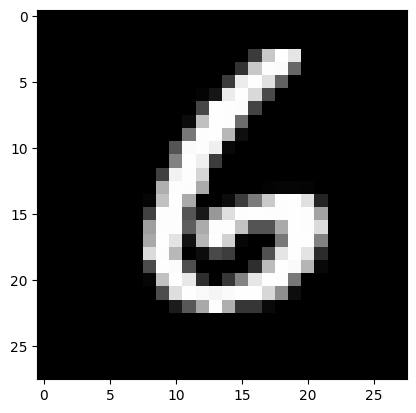

In [27]:
# Por ejemplo, se muestra la imagen 1:

imagen = X[6000].reshape(28,28)
etiqueta = y[6000]

print(f"Etiqueta de la imagen: {etiqueta}")
plt.imshow(imagen, cmap="gray")
plt.show()

In [28]:
# Se seleccionan los grupos de imagenes y etiquetas para el entrenamiento
# y las pruebas. No se debe probar con el mismo grupo de entrenamiento (sesgos).
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=5)

In [29]:
# Tomo sólo un grupo de datos. Si usamos todos tardará tiempo considerable 
# en el entrenamiento y predicción

X_train = X_train
y_train = y_train

X_test = X_test
y_test = y_test

In [30]:
len(X_train)

56000

In [35]:
# Uso de máquinas de soporte vectorial (SVM) para clasificación

rf = RandomForestClassifier(n_estimators=100, random_state=5,
    n_jobs=-1  # usa todos los núcleos del CPU (acelera)
    ) # Se crea el modelo de Random Forest
rf.fit(X_train, y_train) # Entrenamiento del modelo
y_pred = rf.predict(X_test) # Se obtienen las predicciones con el modelo entrenado

In [36]:
from sklearn.metrics import classification_report

rp = classification_report(y_test, y_pred)
print(rp)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1389
           1       0.98      0.99      0.99      1593
           2       0.96      0.97      0.96      1409
           3       0.96      0.95      0.95      1407
           4       0.97      0.98      0.98      1348
           5       0.97      0.96      0.96      1266
           6       0.98      0.98      0.98      1380
           7       0.97      0.97      0.97      1494
           8       0.95      0.96      0.96      1333
           9       0.96      0.95      0.96      1381

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000




Procesando: numeros_01.jpg


<>:4: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
<>:4: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_14956\3421328261.py:4: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
  path = "C:\VisionArtificial\ExU3\img"


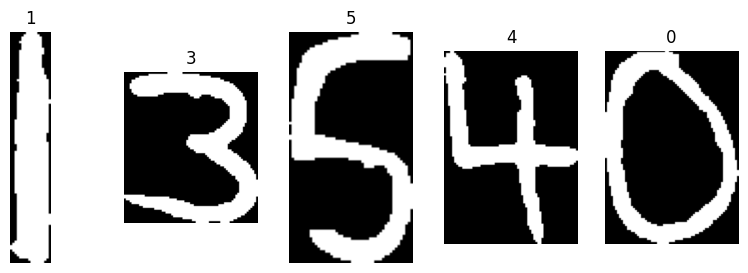

Dígitos detectados: 13540

Procesando: numeros_02.jpeg


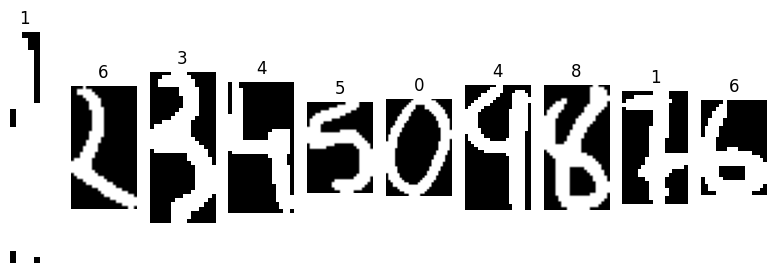

Dígitos detectados: 1634504816

Procesando: numeros_03.jpg


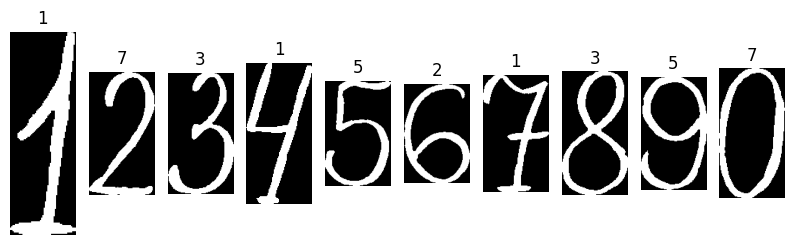

Dígitos detectados: 1731521357


In [37]:
# 4. PROCESAR IMÁGENES DE CARPETA
# ================================

path = "C:\VisionArtificial\ExU3\img"
files = os.listdir(path)

for file in files:
    if not (file.endswith(".jpg") or file.endswith(".png") or file.endswith(".jpeg")):
        continue

    ruta = os.path.join(path, file)
    img = cv2.imread(ruta)

    print(f"\nProcesando: {file}")

    # Preprocesamiento
    img_bin = preprocesar_imagen(img)

    # Segmentación
    digitos = segmentar_digitos(img_bin)

    resultados = []

    plt.figure(figsize=(10,3))

    for i, dig in enumerate(digitos):
        entrada = preparar_digito(dig)

        pred = rf.predict(entrada)[0]
        resultados.append(pred)

        # Mostrar cada dígito
        plt.subplot(1, len(digitos), i+1)
        plt.imshow(dig, cmap='gray')
        plt.title(f"{pred}")
        plt.axis('off')

    plt.show()

    print("Dígitos detectados:", "".join(resultados))